# PRT-Recovery-Seismic-Data-System-

In [1]:
import os
from obspy import read
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from datetime import datetime, timedelta

## Data detection from the data center for recovery

### Functions

In [ ]:
def analizar_archivos(ruta):
    stream = read(ruta)
    print(stream)
    #stream.plot()
    return stream

def selecting_folders(tuple_names, desire_folder):
    desire_folders  = []
    for name in desire_folder:
        desire_folders.append(name + '.D')
    common_elements = list(set(desire_folders) & set(tuple_names))
    # common_elements = [x for x in tuple_names if x in desire_folders] #find folders in order
    return common_elements


def find_namefile_sizes(f_path, folders_names):
    files_and_sizes = []

    for i in folders_names:
        folder_path = os.path.join(f_path, i)

        if not os.path.exists(folder_path):
            print(f"[WARNING] Folder not found: {folder_path}")
            continue   # skip missing folders

        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)

            if os.path.isfile(file_path):
                size = os.path.getsize(file_path)
                files_and_sizes.append((file, size))

    if not files_and_sizes:
        print("[INFO] No files found in the given path(s).")

    return files_and_sizes


def make_sort_key(
    key_sort,
    #channel_order={"HHZ": 0, "HHN": 1, "HHE": 2, "HNZ": 3, "HNN": 4, "HNE": 5}
    desired_order
):
    channel_order={desired_order[0]: 0, desired_order[1]: 1, desired_order[2]: 2, desired_order[3]: 3, desired_order[4]: 4, desired_order[5]: 5}
    def sort_key(item):
        name, size = item
        parts = name.split(".")
        channel = parts[3]
        day = int(parts[6])

        if key_sort == "size":
            return (-size, channel_order[channel], day)

        elif key_sort == "channel":
            return (channel_order[channel], day)

        else:
            raise ValueError(f"Unknown key_sort: {key_sort}")

    return sort_key


def find_missing_ranges(data, channel):
    # collect days for the selected channel
    days = sorted({
        int(name.split(".")[6])
        for name, _ in data
        if name.split(".")[3] == channel
    })
    if not days:
        return [], []

    days_set = set(days)

    # scan between min and max day to find missing contiguous ranges
    print("Total days " + str(channel) + ' : ' + str(days[-1] - days[0]))
    missing = [d for d in range(days[0], days[-1] + 1) if d not in days_set]

    ranges = []
    if missing:
        start = prev = missing[0]
        for d in missing[1:]:
            if d == prev + 1:
                prev = d
            else:
                ranges.append((start, prev))
                start = prev = d
        ranges.append((start, prev))

    return ranges, days  


def build_missing_files(country, station, channel, tipe_data, year, ranges):
    out = []
    for a, b in ranges:
        out.extend([f"{country}.{station}..{channel}.{tipe_data}.{year}.{d}" for d in range(a, b + 1)])
    return out


def print_file_names(data, country, station, tipe_data, year):
    print('Missing packages in each channel')
    for i in data:
        print(i[0])
        print(i[1])
        missing_files = build_missing_files(country, station, i[0],tipe_data, year, i[1])
        print(missing_files)
    return


def print_number_files(desire_channel, data_sort):
    data_ok = []                                               
    miss_data = []
    for channel in desire_channel:
        ranges, present_days = find_missing_ranges(data_sort, channel)
        data_ok.append([channel, present_days])
        miss_data.append([channel, ranges])

    filtered_miss = [x for x in miss_data if x[1]]
    print("Present:", data_ok)
    print("Missing ranges:", filtered_miss) 
    return data_ok, filtered_miss


def print_miss_files(miss_data):
    values = []
    for n in miss_data[0][1]:
        values.append(n[1] + 1 - n[0])

    total = 0
    for v in values:
        total += v
    print("N missed files : "+ str(total))
    return

def main_datacenter (path, channels, treshold):
    # Get the list of all files and directories in the folder
    entries = os.listdir(path)
    #print(entries)
    folders = selecting_folders(entries, channels)
    #print(folders)
    namef_and_sizes = find_namefile_sizes (path, folders)
    country, statio, data_type, year = namef_and_sizes[0][0].split(".")[0], namef_and_sizes[0][0].split(".")[1], namef_and_sizes[0][0].split(".")[4], namef_and_sizes[0][0].split(".")[5]
    print(country, statio, data_type, year)

    # order files by size, name and date
    data_sort_size = sorted(namef_and_sizes, key = make_sort_key('size', channels))
    #print(data)
    data_over  = [x for x in data_sort_size if x[1] >= treshold]
    #data_under = [x for x in data_sorted if x[1] < TRESHOLD]
    data_sort_channel = sorted(data_over, key = make_sort_key('channel', channels))
    print(len(data_sort_size), len(data_over), len(data_sort_channel)) #, len(data_under))
    #print(data_sort_channel)

    _, missing_data = print_number_files(channels, data_sort_channel)
    print_miss_files(missing_data)

    print_file_names(missing_data, country, statio, data_type, year)
    return country, statio, data_type, year, missing_data, folders


### Information will be recover from the station ARNL

In [5]:
folders_path = 'datasets/ARNL (datacenter)/'
#folders_path = 'datasets/CHL2 (datacenter)/'
#folders_path = 'datasets/PPLP (datacenter)/'
DESIRE_CHANNELS = ['HHZ','HHN','HHE', 'HNZ','HNN','HNE']
TRESHOLD = 6000000

COUNTRY_CODE, STATION_CODE, DATA_TYPE, YEAR, missing_data_arnl, folders_arnl = main_datacenter (folders_path, DESIRE_CHANNELS, TRESHOLD)

EC ARNL D 2024
204 171 171
Total days HHZ : 101
Total days HHN : 101
Total days HHE : 101
Total days HNZ : 95
Total days HNN : 95
Total days HNE : 95
Present: [['HHZ', [92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 185, 186, 187, 193]], ['HHN', [92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 185, 186, 187, 193]], ['HHE', [92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 185, 186, 187, 193]], ['HNZ', [92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 185, 186, 187]], ['HNN', [92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 185, 186, 187]], ['HNE', [92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113,

### Information will be recover from the station CHL2

In [8]:
#folders_path = 'datasets/ARNL (datacenter)/'
folders_path = 'datasets/CHL2 (datacenter)/'
#folders_path = 'datasets/PPLP (datacenter)/'
DESIRE_CHANNELS = ['HHZ','HHN','HHE', 'HNZ','HNN','HNE']
TRESHOLD = 6000000
COUNTRY_CODE, STATION_CODE, DATA_TYPE, YEAR, missing_data_chl2, folders_chl2 = main_datacenter (folders_path, DESIRE_CHANNELS, TRESHOLD)


EC CHL2 D 2024
42 36 36
Total days HHZ : 20
Total days HHN : 20
Total days HHE : 20
Present: [['HHZ', [172, 173, 174, 175, 176, 185, 186, 188, 189, 190, 191, 192]], ['HHN', [172, 173, 174, 175, 176, 185, 186, 188, 189, 190, 191, 192]], ['HHE', [172, 173, 174, 175, 176, 185, 186, 188, 189, 190, 191, 192]], ['HNZ', []], ['HNN', []], ['HNE', []]]
Missing ranges: [['HHZ', [(177, 184), (187, 187)]], ['HHN', [(177, 184), (187, 187)]], ['HHE', [(177, 184), (187, 187)]]]
N missed files : 9
Missing packages in each channel
HHZ
[(177, 184), (187, 187)]
['EC.CHL2..HHZ.D.2024.177', 'EC.CHL2..HHZ.D.2024.178', 'EC.CHL2..HHZ.D.2024.179', 'EC.CHL2..HHZ.D.2024.180', 'EC.CHL2..HHZ.D.2024.181', 'EC.CHL2..HHZ.D.2024.182', 'EC.CHL2..HHZ.D.2024.183', 'EC.CHL2..HHZ.D.2024.184', 'EC.CHL2..HHZ.D.2024.187']
HHN
[(177, 184), (187, 187)]
['EC.CHL2..HHN.D.2024.177', 'EC.CHL2..HHN.D.2024.178', 'EC.CHL2..HHN.D.2024.179', 'EC.CHL2..HHN.D.2024.180', 'EC.CHL2..HHN.D.2024.181', 'EC.CHL2..HHN.D.2024.182', 'EC.CHL2..HHN.D

### Information will be recover from the station PPLP

In [4]:
folders_path = 'datasets/PPLP (datacenter)/'
DESIRE_CHANNELS = ['HHZ','HHN','HHE', 'HNZ','HNN','HNE']
TRESHOLD = 6000000
COUNTRY_CODE, STATION_CODE, DATA_TYPE, YEAR, missing_data_pplp, folders_pplp = main_datacenter (folders_path, DESIRE_CHANNELS, TRESHOLD)

EC PPLP D 2023
81 45 45
Total days HHZ : 28
Total days HHN : 28
Total days HHE : 28
Present: [['HHZ', [39, 40, 45, 51, 52, 54, 55, 56, 57, 58, 59, 60, 61, 62, 67]], ['HHN', [39, 40, 45, 51, 52, 54, 55, 56, 57, 58, 59, 60, 61, 62, 67]], ['HHE', [39, 40, 45, 51, 52, 54, 55, 56, 57, 58, 59, 60, 61, 62, 67]], ['HNZ', []], ['HNN', []], ['HNE', []]]
Missing ranges: [['HHZ', [(41, 44), (46, 50), (53, 53), (63, 66)]], ['HHN', [(41, 44), (46, 50), (53, 53), (63, 66)]], ['HHE', [(41, 44), (46, 50), (53, 53), (63, 66)]]]
N missed files : 14
Missing packages in each channel
HHZ
[(41, 44), (46, 50), (53, 53), (63, 66)]
['EC.PPLP..HHZ.D.2023.41', 'EC.PPLP..HHZ.D.2023.42', 'EC.PPLP..HHZ.D.2023.43', 'EC.PPLP..HHZ.D.2023.44', 'EC.PPLP..HHZ.D.2023.46', 'EC.PPLP..HHZ.D.2023.47', 'EC.PPLP..HHZ.D.2023.48', 'EC.PPLP..HHZ.D.2023.49', 'EC.PPLP..HHZ.D.2023.50', 'EC.PPLP..HHZ.D.2023.53', 'EC.PPLP..HHZ.D.2023.63', 'EC.PPLP..HHZ.D.2023.64', 'EC.PPLP..HHZ.D.2023.65', 'EC.PPLP..HHZ.D.2023.66']
HHN
[(41, 44), (46, 5

## Station - files correlation

### Functions

In [ ]:
def julian_to_date(year, julian_day):
    start_of_year = datetime(year, 1, 1)
    date = start_of_year + timedelta(days=julian_day - 1)
    return date.date()
# Example
#print(julian_to_date(2024, 34))

def build_nanometrics_files_format(country, station, elements, model, serial, year, month, day):
    out = []
    for folder in elements:
        for i in range(0, 240000, 10000):
            #print(folder.split(".")[0])
            nano_name_structure = country + "." + station + ".." + folder.split(".")[0] + "_" + model + "_" + serial + "_" + year + month + day + '_' + f"{i:06d}" +'.miniseed'
            out.append(nano_name_structure)
    return out

def find_missing_ranges(data):
    print(data)
    ranges = [x[1] for x in data]
    all_same = all(r == ranges[0] for r in ranges)
    if all_same:
        range = ranges[0]
        print("Same ranges" + str(range))
    else:
        range = ranges
        print( "Different ranges in channels")
    return range

def main_nano_station(range_channel, missing_data, path, treshold_down, treshold_up, folders, datalogger, serial, year):
    for i in range_channel:
        for j in range(i[0], i[1]+1):
            print(j)
            #print(missing_data[0][1][0][0])
            missed_date = julian_to_date(int(year), j)#missing_data[0][1][0][0])
            print(missed_date)#, type(missed_date))
            #print(missed_date.day, missed_date.month, missed_date.year)
            day_str   = f"{missed_date.day:02d}"
            month_str = f"{missed_date.month:02d}"
            year_str  = str(missed_date.year)

            missed_folder_path = path + year_str + "/" + month_str + "/"
            print(missed_folder_path)
            name_missed_and_sizes = find_namefile_sizes (missed_folder_path, [day_str])
            #print(name_missed_and_sizes)

            data_over_station  = [x[0] for x in name_missed_and_sizes if x[1] >= treshold_down and x[1] <= treshold_up]
            #print(len(data_over_station), len(name_missed_and_sizes), data_over_station)

            files_station_nano = build_nanometrics_files_format(COUNTRY_CODE, STATION_CODE, folders, datalogger, serial, year_str, month_str, day_str)
            print(files_station_nano)

            missed_station_elements = list(set(files_station_nano) - set(data_over_station))
            if len(missed_station_elements) == 0:
                print('All elements will be recovered')
            else:
                print('In the data stataion there are ' + str(len(missed_station_elements)) + ' missed files.')
            print("The files to be recovered  of " + str(missed_date) + " are : " + str(len(files_station_nano)))
            #for i in files_station_nano:
            #    print(missed_folder_path + day_str + '/'+ i)
    return


def main_kine_station(range_channel, year, data, missed_folder_path, country, station, lcq, protocol, treshold_down, treshold_up):
    for i in range_channel:
        for j in range(i[0], i[1]+1):
            print(j)
            missed_date = julian_to_date(int(year), j)#missing_data[0][1][0][0])
            print(missed_date)#, type(missed_date))
            #print(missed_date.day, missed_date.month, missed_date.year)
            day_str   = f"{missed_date.day:02d}"
            month_str = f"{missed_date.month:02d}"
            year_str  = str(missed_date.year)

            name_missed_and_sizes = find_namefile_sizes (missed_folder_path, ["sdata/"])
            #print(name_missed_and_sizes)
            data_over_station  = [x[0] for x in name_missed_and_sizes if x[1] >= treshold_down and x[1] <= treshold_up]
            print(len(name_missed_and_sizes), len(data_over_station))
            #print(data_over_station)
            kine_name_structure = country + "-" + station + "_" + lcq + "-" + protocol + "-" + year_str + month_str + day_str
            print(kine_name_structure)

            matches = [x for x in data_over_station if x.startswith(kine_name_structure)]
            print(len(matches))

            if len(matches) == 0:
                print('All elements will be recovered')
            else:
                print('In the data stataion there are ' + str(len(kine_name_structure)) + ' missed files.')
                print("The files to be recovered  of " + str(missed_date) + " are : " + str(len(kine_name_structure)))

    return

### Station CHL2 -Nanometrics-

In [10]:
print_file_names(missing_data_chl2, COUNTRY_CODE, STATION_CODE, DATA_TYPE, YEAR)

Missing packages in each channel
HHZ
[(177, 184), (187, 187)]
['EC.CHL2..HHZ.D.2024.177', 'EC.CHL2..HHZ.D.2024.178', 'EC.CHL2..HHZ.D.2024.179', 'EC.CHL2..HHZ.D.2024.180', 'EC.CHL2..HHZ.D.2024.181', 'EC.CHL2..HHZ.D.2024.182', 'EC.CHL2..HHZ.D.2024.183', 'EC.CHL2..HHZ.D.2024.184', 'EC.CHL2..HHZ.D.2024.187']
HHN
[(177, 184), (187, 187)]
['EC.CHL2..HHN.D.2024.177', 'EC.CHL2..HHN.D.2024.178', 'EC.CHL2..HHN.D.2024.179', 'EC.CHL2..HHN.D.2024.180', 'EC.CHL2..HHN.D.2024.181', 'EC.CHL2..HHN.D.2024.182', 'EC.CHL2..HHN.D.2024.183', 'EC.CHL2..HHN.D.2024.184', 'EC.CHL2..HHN.D.2024.187']
HHE
[(177, 184), (187, 187)]
['EC.CHL2..HHE.D.2024.177', 'EC.CHL2..HHE.D.2024.178', 'EC.CHL2..HHE.D.2024.179', 'EC.CHL2..HHE.D.2024.180', 'EC.CHL2..HHE.D.2024.181', 'EC.CHL2..HHE.D.2024.182', 'EC.CHL2..HHE.D.2024.183', 'EC.CHL2..HHE.D.2024.184', 'EC.CHL2..HHE.D.2024.187']


In [11]:
range_chl2 = find_missing_ranges(missing_data_chl2)

[['HHZ', [(177, 184), (187, 187)]], ['HHN', [(177, 184), (187, 187)]], ['HHE', [(177, 184), (187, 187)]]]
Same ranges[(177, 184), (187, 187)]


In [15]:
archive_path = "datasets/CHL2 (station)/"
TRESHOLD_NANOMETRICS_down = 400000 #450000 
TRESHOLD_NANOMETRICS_up = 600000 #450100
DATALOGGER_MODEL = 'centaur-3'
SERIAL_DATALOGGER = '0259'

main_nano_station(range_chl2, missing_data_chl2, archive_path, TRESHOLD_NANOMETRICS_down, TRESHOLD_NANOMETRICS_up, folders_chl2, DATALOGGER_MODEL, SERIAL_DATALOGGER, YEAR)

177
2024-06-25
datasets/CHL2 (station)/2024/06/
['EC.CHL2..HHE_centaur-3_0259_20240625_000000.miniseed', 'EC.CHL2..HHE_centaur-3_0259_20240625_010000.miniseed', 'EC.CHL2..HHE_centaur-3_0259_20240625_020000.miniseed', 'EC.CHL2..HHE_centaur-3_0259_20240625_030000.miniseed', 'EC.CHL2..HHE_centaur-3_0259_20240625_040000.miniseed', 'EC.CHL2..HHE_centaur-3_0259_20240625_050000.miniseed', 'EC.CHL2..HHE_centaur-3_0259_20240625_060000.miniseed', 'EC.CHL2..HHE_centaur-3_0259_20240625_070000.miniseed', 'EC.CHL2..HHE_centaur-3_0259_20240625_080000.miniseed', 'EC.CHL2..HHE_centaur-3_0259_20240625_090000.miniseed', 'EC.CHL2..HHE_centaur-3_0259_20240625_100000.miniseed', 'EC.CHL2..HHE_centaur-3_0259_20240625_110000.miniseed', 'EC.CHL2..HHE_centaur-3_0259_20240625_120000.miniseed', 'EC.CHL2..HHE_centaur-3_0259_20240625_130000.miniseed', 'EC.CHL2..HHE_centaur-3_0259_20240625_140000.miniseed', 'EC.CHL2..HHE_centaur-3_0259_20240625_150000.miniseed', 'EC.CHL2..HHE_centaur-3_0259_20240625_160000.miniseed',

### Station PPLP -Kinemetrics-

In [32]:
print_file_names(missing_data_pplp, COUNTRY_CODE, STATION_CODE, DATA_TYPE, YEAR)

Missing packages in each channel
HHZ
[(41, 44), (46, 50), (53, 53), (63, 66)]
['EC.PPLP..HHZ.D.2023.41', 'EC.PPLP..HHZ.D.2023.42', 'EC.PPLP..HHZ.D.2023.43', 'EC.PPLP..HHZ.D.2023.44', 'EC.PPLP..HHZ.D.2023.46', 'EC.PPLP..HHZ.D.2023.47', 'EC.PPLP..HHZ.D.2023.48', 'EC.PPLP..HHZ.D.2023.49', 'EC.PPLP..HHZ.D.2023.50', 'EC.PPLP..HHZ.D.2023.53', 'EC.PPLP..HHZ.D.2023.63', 'EC.PPLP..HHZ.D.2023.64', 'EC.PPLP..HHZ.D.2023.65', 'EC.PPLP..HHZ.D.2023.66']
HHN
[(41, 44), (46, 50), (53, 53), (63, 66)]
['EC.PPLP..HHN.D.2023.41', 'EC.PPLP..HHN.D.2023.42', 'EC.PPLP..HHN.D.2023.43', 'EC.PPLP..HHN.D.2023.44', 'EC.PPLP..HHN.D.2023.46', 'EC.PPLP..HHN.D.2023.47', 'EC.PPLP..HHN.D.2023.48', 'EC.PPLP..HHN.D.2023.49', 'EC.PPLP..HHN.D.2023.50', 'EC.PPLP..HHN.D.2023.53', 'EC.PPLP..HHN.D.2023.63', 'EC.PPLP..HHN.D.2023.64', 'EC.PPLP..HHN.D.2023.65', 'EC.PPLP..HHN.D.2023.66']
HHE
[(41, 44), (46, 50), (53, 53), (63, 66)]
['EC.PPLP..HHE.D.2023.41', 'EC.PPLP..HHE.D.2023.42', 'EC.PPLP..HHE.D.2023.43', 'EC.PPLP..HHE.D.2023.44

In [36]:
archive_path = "datasets/PPLP (station)/"
TRESHOLD_KINEMETRICS_down = 60000 #60000
TRESHOLD_KINEMETRICS_up = 110000 #180000
LCQ = '4'
PROTOCOL_MAPPING = 'S'
range_pplp = find_missing_ranges(missing_data_pplp)
print(missing_data_pplp)
main_kine_station(range_pplp, YEAR, missing_data_pplp, archive_path, COUNTRY_CODE, STATION_CODE, LCQ, PROTOCOL_MAPPING, TRESHOLD_KINEMETRICS_down, TRESHOLD_KINEMETRICS_up)

[['HHZ', [(41, 44), (46, 50), (53, 53), (63, 66)]], ['HHN', [(41, 44), (46, 50), (53, 53), (63, 66)]], ['HHE', [(41, 44), (46, 50), (53, 53), (63, 66)]]]
Same ranges[(41, 44), (46, 50), (53, 53), (63, 66)]
[['HHZ', [(41, 44), (46, 50), (53, 53), (63, 66)]], ['HHN', [(41, 44), (46, 50), (53, 53), (63, 66)]], ['HHE', [(41, 44), (46, 50), (53, 53), (63, 66)]]]
41
2023-02-10
333 170
EC-PPLP_4-S-20230210
10
In the data stataion there are 20 missed files.
The files to be recovered  of 2023-02-10 are : 20
42
2023-02-11
333 170
EC-PPLP_4-S-20230211
7
In the data stataion there are 20 missed files.
The files to be recovered  of 2023-02-11 are : 20
43
2023-02-12
333 170
EC-PPLP_4-S-20230212
9
In the data stataion there are 20 missed files.
The files to be recovered  of 2023-02-12 are : 20
44
2023-02-13
333 170
EC-PPLP_4-S-20230213
8
In the data stataion there are 20 missed files.
The files to be recovered  of 2023-02-13 are : 20
46
2023-02-15
333 170
EC-PPLP_4-S-20230215
9
In the data stataion t

## Plots of the seismic data

In [12]:
path_file_s0 = "datasets/PPLP (station)/data/EC-PPLP_4-20230208011003"
data_s0 = analizar_archivos(path_file_s0)
print(data_s0.__str__(extended=True))

35 Trace(s) in Stream:

EC.PPLP..LOG | 2023-02-07T22:54:12.830000Z - 2023-02-07T22:54:12.830000Z | 0.0 s, 833 samples
...
(33 other traces)
...
EC.PPLP..LCE | 2023-02-07T22:23:22.000000Z - 2023-02-08T00:11:30.000000Z | 1.0 Hz, 6489 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]
35 Trace(s) in Stream:
EC.PPLP..LOG | 2023-02-07T22:54:12.830000Z - 2023-02-07T22:54:12.830000Z | 0.0 s, 833 samples
EC.PPLP..LOG | 2023-02-07T23:00:30.500000Z - 2023-02-07T23:00:30.500000Z | 0.0 s, 227 samples
EC.PPLP..LOG | 2023-02-07T23:03:46.950000Z - 2023-02-07T23:03:46.950000Z | 0.0 s, 3834 samples
EC.PPLP..LOG | 2023-02-07T23:04:06.530000Z - 2023-02-07T23:04:06.530000Z | 0.0 s, 3639 samples
EC.PPLP..LOG | 2023-02-07T23:11:48.550000Z - 2023-02-07T23:11:48.550000Z | 0.0 s, 147 samples
EC.PPLP..LOG | 2023-02-07T23:14:37.550000Z - 2023-02-07T23:14:37.550000Z | 0.0 s, 2529 samples
EC.PPLP..LOG | 2023-02-07T23:15:40.490000Z - 2023-02-07T23:15:40.490000Z | 0.0 s, 832 samples
EC.PPLP..L

In [13]:
path_file_s0 = "datasets/PPLP (station)/sdata/EC-PPLP_4-S-20230306113344"
data_s0 = analizar_archivos(path_file_s0)
print(data_s0.__str__(extended=True))

29 Trace(s) in Stream:

EC.PPLP..LOG | 2023-03-06T09:17:02.060000Z - 2023-03-06T09:17:02.060000Z | 0.0 s, 148 samples
...
(27 other traces)
...
EC.PPLP..ACE | 2023-03-06T07:14:59.000000Z - 2023-03-06T07:14:59.000000Z | 0.0 s, 0 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]
29 Trace(s) in Stream:
EC.PPLP..LOG | 2023-03-06T09:17:02.060000Z - 2023-03-06T09:17:02.060000Z | 0.0 s, 148 samples
EC.PPLP..LOG | 2023-03-06T09:28:20.060000Z - 2023-03-06T09:28:20.060000Z | 0.0 s, 147 samples
EC.PPLP..LOG | 2023-03-06T09:32:22.240000Z - 2023-03-06T09:32:22.240000Z | 0.0 s, 3710 samples
EC.PPLP..LOG | 2023-03-06T09:32:43.290000Z - 2023-03-06T09:32:43.290000Z | 0.0 s, 3800 samples
EC.PPLP..LOG | 2023-03-06T09:34:00.400000Z - 2023-03-06T09:34:00.400000Z | 0.0 s, 2236 samples
EC.PPLP..LOG | 2023-03-06T09:39:38.400000Z - 2023-03-06T09:39:38.400000Z | 0.0 s, 228 samples
EC.PPLP..LOG | 2023-03-06T09:50:56.440000Z - 2023-03-06T09:50:56.440000Z | 0.0 s, 147 samples
EC.PPLP..LOG |

1 Trace(s) in Stream:
EC.CHL2..HHE | 2024-06-20T00:00:00.000000Z - 2024-06-20T00:59:59.990000Z | 100.0 Hz, 360000 samples


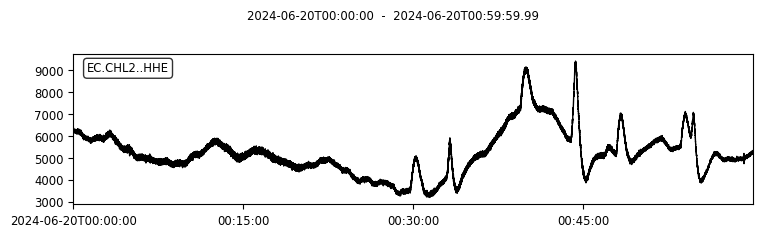

In [3]:
path_file_s0 = "datasets/CHL2 (station)/2024/06/20/EC.CHL2..HHE_centaur-3_0259_20240620_000000.miniseed"
data_s0 = analizar_archivos(path_file_s0)

2 Trace(s) in Stream:
EC.CHL2..HHE | 2024-06-20T00:00:02.010000Z - 2024-06-20T20:17:30.960000Z | 100.0 Hz, 7304896 samples
EC.CHL2..HHE | 2024-06-20T20:17:58.610000Z - 2024-06-21T00:00:02.820000Z | 100.0 Hz, 1332422 samples


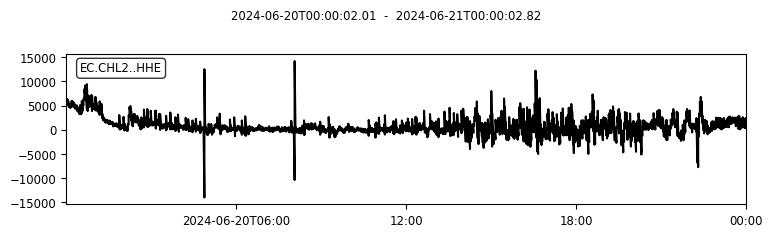

In [4]:
path_file_dc0 = "datasets/CHL2 (datacenter)/HHE.D/EC.CHL2..HHE.D.2024.172"
data_dc0= analizar_archivos(path_file_dc0)

In [5]:
# Specify the folder path
folder_path = 'datasets/CHL2 (datacenter)/HHN.D'

# Get the list of all files and directories in the folder
files = os.listdir(folder_path)

# Create a list of tuples containing file name and size
file_sizes = []

for file in files:
    file_path = os.path.join(folder_path, file)
    if os.path.isfile(file_path):
        size = os.path.getsize(file_path)  # Get the size of the file in bytes
        file_sizes.append((file, size))

# Print the file names and their sizes
for file, size in file_sizes:
    print(f"{file}: {size} bytes")

EC.CHL2..HHN.D.2024.184: 386048 bytes
EC.CHL2..HHN.D.2024.191: 11486720 bytes
EC.CHL2..HHN.D.2024.174: 10833920 bytes
EC.CHL2..HHN.D.2024.185: 10905088 bytes
EC.CHL2..HHN.D.2024.189: 10818560 bytes
EC.CHL2..HHN.D.2024.192: 11020288 bytes
EC.CHL2..HHN.D.2024.175: 10785792 bytes
EC.CHL2..HHN.D.2024.188: 11207168 bytes
EC.CHL2..HHN.D.2024.190: 11461632 bytes
EC.CHL2..HHN.D.2024.173: 11190784 bytes
EC.CHL2..HHN.D.2024.187: 5278208 bytes
EC.CHL2..HHN.D.2024.186: 10351616 bytes
EC.CHL2..HHN.D.2024.176: 7745024 bytes
EC.CHL2..HHN.D.2024.172: 10844160 bytes


In [6]:
folder_path = 'datasets/CHL2 (datacenter)/'

# Get the list of all files and directories in the folder
entries = os.listdir(folder_path)

# Create a list of tuples containing the entry name and its size
#entry_sizes = []
folders = ['HHZ.D','HHN.D','HHE.D', 'HNZ.D','HNN.D','HNE.D']
print(entries)
#for entry in entries:
    #entry_sizes.append((entry))

# Print the names and sizes of entries (files and folders)
#for entry, size in entry_sizes:
#    print(f"{entry}: {size}")

['HHE.D', 'VCO.D', 'HHZ.D', 'HHN.D', 'GAN.D', 'GNS.D', 'VPB.D']
